In [ ]:
# Sensor fusion
Camera, IMU, Lidar, Radar, GPS

# Calibrate the sensor
# Identify the sensor parameters &  estimate the pose / ref frame

# Transform to a common ref frame
# Time offset between sensor pooling times -> combine synchronised information

# Frequency? Update rates (15-30Hz good)

In [443]:
import numpy as np
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from enum import Enum
import time

GRAVITY = 9.81
%matplotlib inline

In [681]:
def get_rotation_matrix(axis, theta):
    """Compute the rotation matrix using Rodrigues' formula."""
    axis = axis / np.linalg.norm(axis)  # Normalize axis
    ux, uy, uz = axis

    K = np.array([[0, -uz, uy],
                  [uz, 0, -ux],
                  [-uy, ux, 0]])
    
    I = np.eye(3)  # Identity matrix

    R = I + np.sin(theta) * K + (1 - np.cos(theta)) * np.dot(K, K)
    return R


import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def rotation_matrix_axis(axis, theta):
    """Return the rotation matrix for rotation about an arbitrary axis."""
    axis = np.asarray(axis)
    axis = axis / np.sqrt(np.dot(axis, axis))
    a = np.cos(theta / 2.0)
    b, c, d = -axis * np.sin(theta / 2.0)
    aa, bb, cc, dd = a*a, b*b, c*c, d*d
    bc, ad, ac, ab, bd, cd = b*c, a*d, a*c, a*b, b*d, c*d
    return np.array([
        [aa+bb-cc-dd, 2*(bc+ad), 2*(bd-ac)],
        [2*(bc-ad), aa+cc-bb-dd, 2*(cd+ab)],
        [2*(bd+ac), 2*(cd-ab), aa+dd-bb-cc]
    ])

def transform_about_point(T_BA, old_points, axis_A, axis_point_A, angle,wrtorigin=True):
    """
    Rotate rectangle about an axis passing through point_A in frame A.
    
    Parameters:
    - T_BA: 4x4 transformation from frame A to B
    - corners_A: Nx3 rectangle corners in frame A
    - axis_A: 3D rotation axis vector in frame A
    - point_A: 3D point in frame A that axis passes through
    - angle: rotation angle in radians
    
    Returns:
    - transformed corners in frame B
    - new transformation matrix T_BA_new
    """

    # Convert to homogeneous coordinates
    old_points_h = np.vstack((old_points, np.ones((1, old_points.shape[1]))))
    
    
    # Create rotation matrix
    R_A = rotation_matrix_axis(axis_A, angle)
    
    # Create transformation for rotation about arbitrary point
    T1 = np.eye(4)
    T1[:3, [3]] = -axis_point_A  # Translate to origin
    
    T2 = np.eye(4)
    T2[:3, :3] = R_A      # Rotate
    
    T3 = np.eye(4)
    T3[:3, [3]] = axis_point_A    # Translate back
    
    # Combined transformation in frame A
    T_AA_prime = T3 @ T2 @ T1

    new_points_h = (T_AA_prime @ old_points_h)
    
    # # New transformation from A to B
    T_BA_new = T_BA @ T_AA_prime
    
    # # Transform all corners
    # corners_B_hom = (T_BA_new @ old_points.T).T

    # Return the points location w.r.to the rotated origin
    if wrtorigin:
        new_points_h -= new_points_h[:,[0]]
        return new_points_h[:3,:],T_BA_new
    # Return the points location w.r.to the axis point
    return new_points_h[:3, :], T_BA_new

def plot_rectangle(ax, corners, color='b', label=''):
    """Plot a rectangle from its corners in 3D space"""
    edges = [[0,1], [1,2], [2,3], [3,0]]
    ax.plot(corners[0,:],corners[1,:],color=color, label=label)

In [682]:
class FrameDrawer:
    def __init__(self, ax=None, length=1.0, name=""):
        self.ax = ax
        self.length = length
        self.name = name
        self.quivers = []
    def set_axes(self,ax):
        self.ax = ax
        
    def draw(self, T,dim=2):
        if self.ax is None:
            raise "Axes is not set to draw frame!"
        # Remove existing quivers if present
        for q in self.quivers:
            q.remove()
        self.quivers = []
        
        origin = T[:dim, 3]
        x_axis = T[:dim, 0] * self.length
        y_axis = T[:dim, 1] * self.length

        qx = self.ax.quiver(*origin, *x_axis, color='r', label=f'{self.name}_x')
        qy = self.ax.quiver(*origin, *y_axis, color='g', label=f'{self.name}_y')
        
        if dim==3:
            z_axis = T[:dim, 2] * self.length
            qz = self.ax.quiver(*origin, *z_axis, color='b', label=f'{self.name}_z')
            self.quivers.extend([qx, qy, qz])
        else:
            self.quivers.extend([qx, qy])

In [683]:
class Point:
    def __init__(self, x=0, y=0, z=0):
        self.x = x
        self.y = y
        self.z = z

    def to_numpy(self):
        return np.array([
            [self.x],
            [self.y],
            [self.z]]
        )
    def __repr__(self):
        return f"Point(%.2f,%.2f,%.2f)" % (self.x,self.y,self.z)
    
    def distance(self, p2):
        e = (self.x-p2.x)**2 + (self.y-p2.y)**2 + (self.z-p2.z)**2
        return np.sqrt(e)


class Vector(Point):
    def __init__(self, x=0, y=0, z=0):
        super().__init__(x, y, z)

    def from_np_array(self, arr):
        self.x = arr[0, 0]
        self.y = arr[1, 0]
        self.z = arr[2, 0]

    def from_np_array(self, arr):
        self.x = arr[0, 0]
        self.y = arr[1, 0]
        self.z = arr[2, 0]

    def dot(self, vec2: Point):
        return self.x * vec2.x+self.y * vec2.y+self.z * vec2.z

    def __repr__(self):
        return f"Vector(%.4f,%.4f,%.4f) " % (self.x,self.y,self.z)
    
    def cross(self, vec2: Point):
        x = self.y * vec2.z - self.z * vec2.y
        y = -(self.x * vec2.z - self.z * vec2.x)
        z = self.x * vec2.y - self.y * vec2.x
        return Vector(x, y, z)

    def __iter__(self):
        return iter((self.x, self.y, self.z))
    
    def __add__(self, operand):
        if isinstance(operand, (int, float)):
            return Vector(self.x + operand, self.y + operand, self.z + operand)
        elif isinstance(operand, Vector):
            return Vector(self.x + operand.x, self.y + operand.y, self.z + operand.z)
        elif isinstance(operand, np.ndarray):
            res = operand.copy()
            m,n = operand.shape
            if (m == 3):
                res[0, :] = self.x + res[0, :]
                res[1, :] = self.y + res[1, :]
                res[2, :] = self.z + res[2, :]
                return res
            else:
                raise TypeError("Addition supports for ndarray with 3 rows!")
        raise TypeError("Addition does not support this type of operand!")

    def __radd__(self, operand):
        return self + operand

    def __sub__(self, operand):
        if isinstance(operand, (int, float)):
            return Vector(self.x - operand, self.y - operand, self.z - operand)
        elif isinstance(operand, Vector):
            return Vector(self.x - operand.x, self.y - operand.y, self.z - operand.z)
        elif isinstance(operand, np.ndarray):
            res = operand.copy()
            m,n = operand.shape
            if (m == 3):
                res[0, :] = self.x - res[0, :]
                res[1, :] = self.y - res[1, :]
                res[2, :] = self.z - res[2, :]
                return res
            else:
                raise TypeError("Substraction supports for ndarray with 3 rows!")
        raise TypeError("Addition does not support this type of operand!")

    def __rsub__(self, operand):
        return -1*(self - operand)

    def __mul__(self, operand):
        if isinstance(operand, (int, float)):
            return Vector(self.x * operand, self.y * operand, self.z * operand)
        elif isinstance(operand, Vector):
            return Vector(self.x * operand.x, self.y * operand.y, self.z * operand.z)
        elif isinstance(operand, np.ndarray):
            res = operand.copy()
            m,n = operand.shape
            if (m == 3):
                res[0, :] = self.x * res[0, :]
                res[1, :] = self.y * res[1, :]
                res[2, :] = self.z * res[2, :]
                return res
            else:
                raise TypeError("Multiplication supports for ndarray with 3 rows!")
        raise TypeError("Addition does not support this type of operand!")

    def __rmul__(self, operand):
        return self * operand


def rotate_vector_quat(quat, vec):
    vec_quat = np.zeros((4, 1))
    vec_quat[1:, 0] = vec
    quat_inv = -quat
    quat_inv[0, 0] = -quat_inv[0, 0]

    return quaternion_mul(quaternion_mul(quat,vec_quat),quat_inv)[1:,0]

def quaternion(theta,vec,deg=True):
    if deg:
        theta = np.radians(theta)
    quat = np.zeros((4,1))
    quat[0,0] = np.cos(theta/2)
    quat[1:,:] = np.sin(theta/2)*vec
    return quat

def quaternion_to_rot_mat(quat)->np.ndarray:
    q_w = quat[0, 0]
    q_v = quat[1:, 0]

    q_vx = np.array([
        [0, -q_v[2], q_v[1]],
        [q_v[2], 0, -q_v[0]],
        [-q_v[1], q_v[0], 0]])

    return (q_w**2 - q_v.T @ q_v)*np.eye(3) + 2 * q_v @ q_v.T + 2*q_w*q_vx


def quaternion_mul(p: np.ndarray, q: np.ndarray):

    p_w = p[0, 0]
    p_v = p[1:, 0]
    q_w = q[0, 0]
    q_v = q[1:, 0]
    p_vx = np.array([
        [0, -p_v[2], p_v[1]],
        [p_v[2], 0, -p_v[0]],
        [-p_v[1], p_v[0], 0]])

    res = np.zeros((4, 1))
    res[0, 0] = p_w*q_w - p_v.T @ q_v
    res[1:, 0] = p_w*q_v + q_w*p_v - p_vx @ q_v

    return res


class Variations(Enum):
    CONSTANT = 1
    LINEAR = 2
    QUADRATIC = 3
    CUBIC = 4
    EXPOTENTIAL = 5


class Model(ABC):
    A: np.ndarray = None
    B: np.ndarray = None
    state: np.ndarray = None
    state_d: np.ndarray = None

    @abstractmethod
    def get_state_space(self):
        pass


In [719]:
class Arm:
    def __init__(self, arm_len=1, origin=(0, 0, 0), arm_width=0.1, arm_thickness=0.1, arm_density=5, arm_density_var=Variations.CONSTANT):
        """
        arm_len : Length of the arm ( in m )
        arm_len : Width of the arm ( in m )
        arm_len : Thickness of the arm ( in m )
        arm_density : Density of the arm matrial (in kg/m)
        arm_density_var : Variation of density of the arm matrial 
        """
        self.arm_len = arm_len
        self.arm_width = arm_width
        self.arm_thickness = arm_thickness
        self.arm_density_var = arm_density_var
        self.conf = Vector(self.arm_len, self.arm_width, self.arm_thickness)
        self.arm_ccp = np.array([[0.5],
                                 [0.5],
                                 [0.0]])
        self.origin = Vector(*origin)
        self.arm_mass = self.calculate_mass(arm_density, arm_density_var)
        self.centroid: Vector = self.calculate_centroid()
        Ixx = self.arm_mass*self.arm_len**2
        Iyy = self.arm_mass*self.arm_width**2
        Izz = self.arm_mass*self.arm_thickness**2
        self.inertia = np.array([[Ixx, 0, 0],
                                 [0, Iyy, 0],
                                 [0, 0, Izz]]
                                )
        self.init_arm = np.array([[0. , self.arm_len ,   self.arm_len,       0.     ],
                                  [0. ,     0.      , self.arm_width, self.arm_width],
                                  [0. ,     0.      ,        0.    ,       0.     ]])
        self.T_BA = np.eye(4)
        self.T_BA[:3,[3]] = self.origin.to_numpy()
        self.orientation = self.T_BA[:3,:3]
        self.arm = self.init_arm.copy() 
        self.arm_plots = []
        self.plot_initialized = False
        self.ax = False
        self.hinge_point = Vector(0,0,0)
        self.frame_drawer = FrameDrawer()

    def get_position_vector(self):
        return self.origin

    def set_position_vector(self, position):
        self.position = position

    def get_origin(self):
        return self.origin

    def set_origin(self, origin:Vector):
        self.T_BA[:3,[3]] = origin.to_numpy()
        self.origin = origin

    def get_orientation(self):
        return self.orientation

    def set_orientation(self, orientation):
        self.orientation = orientation

    def calculate_mass(self, arm_density, variation):
        if variation == Variations.CONSTANT:
            return arm_density*self.arm_len

    def calculate_centroid(self) -> Vector:
        if self.arm_density_var == Variations.CONSTANT:
            return self.conf*0.5
        else:
            raise "Not implemented!"
    
    def rotate(self, axis, theta):
        quat = np.array([
            [np.cos(theta)],
            [axis[0]*np.sin(theta)],
            [axis[1]*np.sin(theta)],
            [axis[2]*np.sin(theta)],
        ])

    def plot(self, ax: plt.Axes = None,length=1,name='arm'):
        if ax is not None:
            self.ax = ax
            self.frame_drawer.set_axes(ax)
            self.plot_initialized = False
        elif(not self.ax):
            raise "Axes is not set!"
            
        if not self.plot_initialized:
            self.plot_initialized = True
            cords = (self.origin + self.arm).T
            self.arm_plots.append(patches.Polygon(cords[:,:2], color='orange', fill=True))

            # Add circle to plot
            # self.joint_plot = self.ax.scatter([x],[y], color='black', s=300, label="Joint",zorder=1)
            self.ax.add_patch(self.arm_plots[0])
            self.arm_plots.append(self.ax.scatter([self.hinge_point.x],[self.hinge_point.y],marker='o' ,s=20,zorder=10))
            
            self.frame_drawer.draw(self.T_BA[:,:])
        else:
            cords = (self.origin + self.arm).T
            self.arm_plots[0].set_xy(cords[:,:2])
            self.frame_drawer.draw(self.T_BA[:,:])

        self.ax.figure.canvas.draw()  
        return self.ax.figure

    def set_hinge_point(self,hinge_point, hinge_point_p=Vector(0, 0, 0)):
        """
        hinge_point : (x,y,z) in percentage of length, width & thickness of arm 
        Eg: (0.5, 0.5, 0.5)
        - 50% of the length 
        - 50% of the width 
        - 50% of the thickness 
        """
        self.hinge_point = self.conf * hinge_point_p 
        self.set_origin(hinge_point - self.hinge_point)
        self.home_pos = self.T_BA.copy()

    def get_hinge_point(self):
        return self.origin + self.hinge_point
        
    def get_inertia_about_hinge(self):
        return self.get_inertia_about(self.hinge_point)

    def get_inertia_about(self, axis):
        return (self.arm_mass*self.arm_len**2 / 3) + self.origin.distance(axis)**2 * self.arm_mass

    def get_centroid(self) -> Vector:
        return self.origin + self.centroid

    def get_mass(self):
        return self.arm_mass
        
    def reset(self):
        self.arm = self.init_arm 
        self.origin = Vector(*self.home_pos[:3,3])
        self.T_BA[:,:] = self.home_pos[:,:]

    def translate(self,translate):
        self.arm[:,:] += translate 
        
    def rotate(self,rotate,quaternion = True):
        if quaternion:
            self.orientation = Vector(0, 0, 2*np.arccos(rotate[0,0])*180/np.pi)
            for i in range(4):
                self.arm[:,i] = rotate_vector_quat(rotate,self.arm[:,i])
        else:
            self.arm[:,:] = rotate @ self.arm 
        
    def rotate_about_hinge(self,theta,radians=True):
        print("Rotating the arm by",theta)
        #Rotation parameters
        axis_A = np.array([0, 0, 1])  # z-axis rotation
        point_A = np.array([1, 0.5, 0])  # Axis passes through (1,0.5,0) in frame A
        
        self.arm[:,:],T_BA_new= transform_about_point(self.T_BA[:,:], self.arm[:,:], axis_A, self.hinge_point.to_numpy(), theta)
        self.T_BA[:3,:] = T_BA_new[:3,:]
        self.orientation = T_BA_new[:3,:3]
        self.origin = Vector(*T_BA_new[:3,3].flatten())

        print("New orientation :",T_BA_new)
        print("New hinge point :",self.get_hinge_point())
        
    def update(self,rotate=None,translate=None):
        if rotate is not None:
            self.rotate(rotate)
        if translate is not None:
            self.translate(translate)

In [720]:
from scipy.linalg import expm
class Joint(Model):
    def __init__(self, joint_name: str,K: float = 0, b: float = 0.3, g=GRAVITY,radius=0.1,del_t = 0.01):
        """ 
        theta : joint angle(position)
        theta_d : joint velocity
        theta_dd : joint acceleration
        J : inertia of the joint
        b : damping coefficient (friction)
        Tau_g : gravitational torque
        m : mass suspended at the joint end
        r_g : diatacne of the centroid of the mass from the joint
        """
        self.joint_name = joint_name
        self.J = 0
        self.radius = radius
        self.K = K
        self.b = b
        self.theta = 0
        self.theta_d = 0
        self.theta_dd = 0
        self.g = Vector(0, g, 0)
        self.origin = Vector(0,0,0)
        self.arm = None
        self.ax: plt.Axes = None
        self.joint_plot = None
        self.plot_initialized = None
        self.state = np.zeros((2,1))
        self.u = np.zeros((2,1))
        self.del_t = del_t
        self.Tau_g = 0
        self.Tau = 0

    def calculate_state_space_params(self,Tg):
        self.A = np.array([[0,    1],
                           [-Tg/self.J,  -self.b/self.J]])
        self.B = np.array([[0,   0],
                           [1/self.J, -1/self.J]])
        s
        # self.C = np.array([[self.del_t,   0],
        #                    [1, self.del_t]])
        # self.D = np.array([[1,0],
        #                    [0,0]])
        # self.C = np.eye(2)
        # self.D = np.eye(2)

        self.A_d,self.B_d = self.to_discrete()
        
    def to_discrete(self,kind='FEULER'):
        """Convert continuous-time state-space to discrete-time"""

        if kind=="ZOH":
            A_d = expm(self.A * self.del_t)  # Discrete-time A matrix
            B_d = np.linalg.inv(self.A) @ (A_d - np.eye(len(self.A))) @ self.B  # Discrete-time B matrix
        elif kind == "FEULER":
            A_d = np.eye(self.A.shape[0]) + self.A * self.del_t # Discrete-time A matrix
            B_d = self.B * self.del_t # Discrete-time B matrix
        elif kind == "BEULER":
            A_d = np.linalg.inv(np.eye(self.A.shape[0]) + self.A * self.del_t) # Discrete-time A matrix
            B_d = A_d @ self.B * self.del_t # Discrete-time B matrix
        
        return A_d, B_d
        
    def get_state_dim(self):
        return 2
        
    def get_control_dim(self):
        return 1
        
    def init_state(self,theta=0,theta_d=0):
        self.state[0,0] = theta
        self.state[1,0] = theta_d

    def init_control_vec(self,Tau_g,Tau=0):
        self.u[0,0]=Tau
        self.u[1,0]=Tau_g
        
    def get_state_space(self):
        return self.state_d,self.state

    def set_torque(self, torque):
        self.Tau = torque
        self.u[0,0]=torque

    def set_inertia(self, inertia):
        self.J = inertia

    def get_state_trans_mat(self):
        """
        Return the state transition mat (A)
        """
        return self.A_d

    def get_input_mat(self):
        """
        Return the input mat (B)
        """
        return self.B_d

    def get_joint_origin(self) -> np.ndarray:
        self.origin

    def predict(self, state,torque):
        u = np.zeros((2,1))
        u[0,0] = torque
        u[1,0] = self.get_gravity_torque()
        # state_d = self.A @ state + self.B @ u
        # return self.C @ state_d + self.D @ state
        return self.A_d @ state + self.B_d @ u
        
    def get_gravity_torque(self):
        return self.Tau_g.z
        
    def calculte_gravity_torque_vector(self):
        """
        r_g : Centroid of the arm (in m)
        m : Mass of the arm (in Kg)
        """
        rg = self.arm.get_orientation() @ (self.arm.get_centroid() - self.arm.get_hinge_point()).to_numpy()
        rg = Vector(*rg.flatten())
        Fg = arm.get_mass() * joint.g
        return Fg.cross(rg)
        
    def set_gravity_torque(self, tau_g: Vector):
        print("Setting gravity torque :",tau_g)
        self.Tau_g = tau_g
        self.u[1,0]=self.Tau_g.z

    def add_arm(self, arm: Arm, hinge_point: Vector):
        if self.arm:
            raise "Arm is already set!"
        else:
            self.arm = arm
    
        self.arm.set_hinge_point(self.origin,hinge_point)
        self.set_inertia(self.arm.get_inertia_about_hinge())
        self.set_gravity_torque(self.calculte_gravity_torque_vector())
        self.calculate_state_space_params(self.get_gravity_torque()/self.thet)

    def plot(self, ax=None):
        if ax is not None:
            self.ax = ax
            self.plot_initialized = False
        elif(not self.ax):
            raise "Axes is not set!"
            
        if not self.plot_initialized:
            self.plot_initialized = True
            x, y, z = self.origin
            self.joint_plot = plt.Circle((0, 0), self.radius, color='b',
                                fill=True, linewidth=2)

            # Add circle to plot
            # self.joint_plot = self.ax.scatter([x],[y], color='black', s=300, label="Joint",zorder=1)
            self.ax.add_patch(self.joint_plot)
        else:
            pass
            # x, y, z = self.origin
            # self.joint_plot.ceter((x,y))
       
        self.ax.figure.canvas.draw()  
        return self.ax.figure

    def rotate_by(self,theta):
        theta = np.radians(theta)
        self.state[0,0] += theta
        self.arm.rotate_about_hinge(theta)
        self.set_gravity_torque(self.calculte_gravity_torque_vector())

    def get_state(self):
        return self.state

    def reset_state(self):
        self.state[0,0] = 0
        self.state[1,0] = 0
        self.set_torque(0)
        self.arm.reset()
        self.set_gravity_torque(self.calculte_gravity_torque_vector())
        
    def update_state(self,torque=None,update_arm=True):
        if torque is not None:
            self.set_torque(torque)
        theta_i = self.state[0,0]
        print("Initial State :",self.state)
        print("Gravity torque acting :",self.Tau_g)
        print("Control input :",self.u)
        self.state[:,:] += self.A_d @ self.state + self.B_d @ self.u
        print("New State :",self.state)
        theta_f = self.state[0,0]
        del_theta = theta_f-theta_i

        # Update the arm state
        if update_arm:
            self.arm.rotate_about_hinge(del_theta)
        # Calculate the new gravity torque acting according to the arm pose
        self.set_gravity_torque(self.calculte_gravity_torque_vector())
        print("Gravity torque acting :",self.Tau_g)

In [721]:
class MPC:
    def __init__(self, model, N=5,w_th=10,w_thd=1,w_u=15):
        self.model = model
        self.N = N
        self.Q = np.diag([w_th,w_thd])  # State cost matrix
        self.R = np.eye(model.get_control_dim()) * w_u # Control effort cost matrix

    def minimize(self, X0, Xr, U_initial, U_constraints, max_iters=100, learning_rate=0.05):
        U = U_initial.copy()  # Copy to avoid modifying the initial guess
        U_history = np.zeros((U_initial.shape[1],max_iters+1))
        U_history[:,0] = U[0,:]
        
        for i in range(1,max_iters+1):
            # Predict trajectory for current control input
            X_pred = self.rollout_trajectory(X0, U)
            
            # Compute cost and gradient
            J, grad_U = self.cost_func(Xr, X_pred, U)

            print(f"J : {J} grad_U : {grad_U} U : {U[0,:]}")
           
            # Gradient descent step
            U -= learning_rate * grad_U  
           
            # Apply control constraints
            U = np.clip(U, U_constraints[0], U_constraints[1])
            U_history[:,i] = U[0,:]

        return U[:, 0],U_history  # Return the first control input

    def cost_func(self, Xr, X_pred, U):
        """Compute cost and gradient."""
        error = X_pred - Xr
        J = np.trace(error.T @ self.Q @ error) + np.trace(U.T @ self.R @ U)
        grad_U = 2 * self.R @ U  # Gradient w.r.t. control input
        
        return J, grad_U

    def rollout_trajectory(self, X0, U):
        """Predict future states using the model."""
        X_traj = np.zeros((X0.shape[0], self.N))
        X_traj[:, 0] = X0.flatten()

        for k in range(1, self.N):
            X_traj[:, [k]] = self.model.predict(X_traj[:, [k - 1]], U[:, k - 1].item())

        return X_traj

    def get_control_input(self, X0, Xr,init_max=True):
        """Compute the optimal control input using MPC."""

        Kgcm_to_Nm = 9.81 / 100  # Conversion factor
        U_constraints = np.array([[-10 * Kgcm_to_Nm], [10 * Kgcm_to_Nm]])  # Torque constraints

        if init_max:
            U = np.ones((1, self.N))*U_constraints[1,0]*0.9
        else:
            U = np.random.uniform(low=-1, high=1, size=(1, self.N))  # Initial guess for control sequence
 
        # Optimize control input
        U_optim ,U_history= self.minimize(X0, Xr, U, U_constraints)
        return U_optim,U_history


In [722]:
T = 5
del_t = 0.1
goal_theta = 180
t = np.arange(0,T+del_t,del_t)

n = t.shape[0]
# theta_r = np.linspace(0,goal_theta,n)

# w = (ref_thetas[1]-ref_thetas[0])/(t[1]-t[0])
# theta_d_r = np.ones(n)*w
theta_r = np.sin(0.5 * t)  # Position reference
theta_d_r = 0.5 * np.cos(0.5 * t)  # Velocity reference (derivative of theta_r)

# Store results for plotting
theta_actual = []
theta_d_actual = []
control_inputs = []

In [723]:
def create_figure(xlim=(-1.1, 1.1),ylim=(-1.1, 1.1)):
    from matplotlib.ticker import MultipleLocator
    plt.ion()  # Enable interactive mode
    fig1 = plt.figure(figsize=(8,8))
    ax = fig1.add_subplot(111)
    ax.set_aspect('equal')
    ax.tick_params(axis='both', which='minor', labelsize=8)
    ax.xaxis.set_major_locator(MultipleLocator(0.1))  # Set major ticks at 0.1 intervals
    ax.yaxis.set_major_locator(MultipleLocator(0.1))  # Set major ticks at 0.1 intervals
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid(which='both', linestyle='--', linewidth=0.5)  # Enables both major & minor grid
    # plt.minorticks_on()
    return ax

(<Figure size 800x800 with 1 Axes>, <Figure size 800x800 with 1 Axes>)

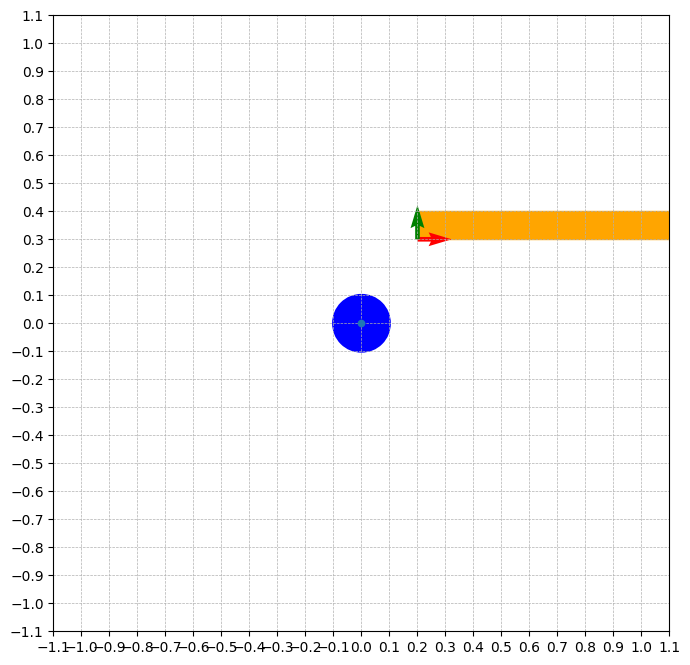

In [724]:
arm = Arm(origin=(0.2,0.3,0))
joint = Joint('joint_1',radius=.1)
ax = create_figure()
joint.plot(ax) , arm.plot(ax)

Setting gravity torque : Vector(2.4525,-0.0000,-14.7150) 


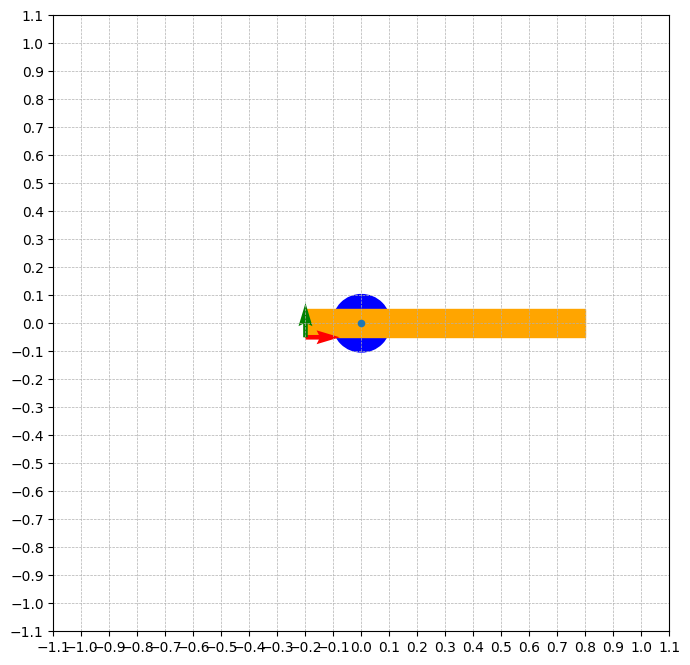

In [725]:
joint.add_arm(arm, Vector(0.2, 0.5, 0))
joint.plot()
arm.plot()

In [726]:
joint.reset_state()

Setting gravity torque : Vector(2.4525,-0.0000,-14.7150) 


Initial State : [[0.]
 [0.]]
Gravity torque acting : Vector(2.4525,-0.0000,-14.7150) 
Control input : [[  0.   ]
 [-14.715]]
New State : [[0.       ]
 [0.0584702]]
Rotating the arm by 0.0
New orientation : [[ 1.    0.    0.   -0.2 ]
 [ 0.    1.    0.   -0.05]
 [ 0.    0.    1.    0.  ]
 [ 0.    0.    0.    1.  ]]
New hinge point : Vector(0.0000,0.0000,0.0000) 
Setting gravity torque : Vector(2.4525,-0.0000,-14.7150) 
Gravity torque acting : Vector(2.4525,-0.0000,-14.7150) 


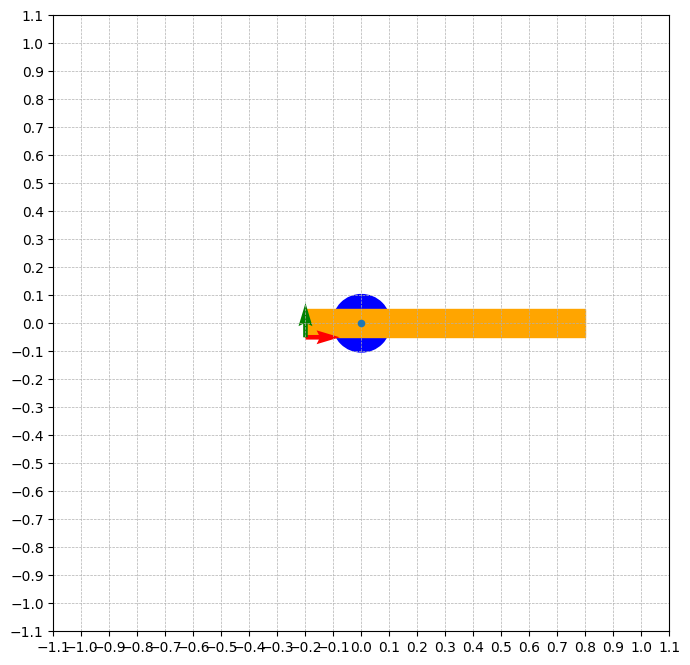

In [727]:
joint.update_state()
joint.plot()
arm.plot()

Setting gravity torque : Vector(2.4525,-0.0000,-14.6568) 
[[ 12.65532915]
 [251.86208245]]


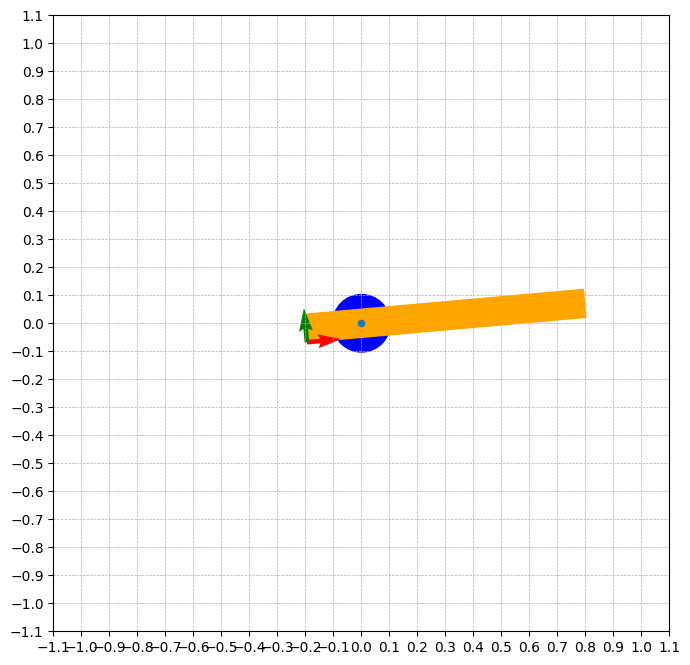

In [702]:
joint.update_state(0.8829)
print(joint.get_state())
joint.plot()
arm.plot()

In [49]:
X_pred = mpc.rollout_trajectory(X0, U)
X_pred

array([[0.00000000e+00, 1.09106341e-01, 1.11114285e+01, 3.12679166e+01,
        5.91171515e+01, 9.34310230e+01, 1.33177483e+02, 1.77489244e+02,
        2.25637477e+02, 2.77009709e+02],
       [1.09106341e-01, 1.10023222e+01, 2.01564880e+01, 2.78492350e+01,
        3.43138715e+01, 3.97464596e+01, 4.43117610e+01, 4.81482337e+01,
        5.13722319e+01, 5.40815341e+01]])

In [8]:
Xr = np.array([[theta_r[0]], [theta_d_r[0]]])  # Reference state [theta, theta_dot]
    
# Compute optimal control input using MPC
u_opt,u_hist = mpc.get_control_input(X0, Xr)
u_opt,u_hist

J : 3798739.5503939395 grad_U : [[17.658 17.658 17.658 17.658 17.658 17.658 17.658 17.658 17.658 17.658]] U : [0.8829 0.8829 0.8829 0.8829 0.8829 0.8829 0.8829 0.8829 0.8829 0.8829]
J : 3478534.791293332 grad_U : [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] U : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
J : 3478534.791293332 grad_U : [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] U : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
J : 3478534.791293332 grad_U : [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] U : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
J : 3478534.791293332 grad_U : [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] U : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
J : 3478534.791293332 grad_U : [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] U : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
J : 3478534.791293332 grad_U : [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] U : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
J : 3478534.791293332 grad_U : [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] U : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
J : 3478534.791293332 grad_U : [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] U : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
J : 347853

(array([0.]),
 array([[0.8829, 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
        [0.8829, 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
        [0.8829, 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
        ...,
        [0.8829, 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
        [0.8829, 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
        [0.8829, 0.    , 0.    , ..., 0.    , 0.    , 0.    ]],
       shape=(10, 101)))

In [122]:

# Execution loop
for i in range(len(t)):
    Xr = np.array([[theta_r[i]], [theta_d_r[i]]])  # Reference state [theta, theta_dot]
    
    # Compute optimal control input using MPC
    u_opt = mpc.get_control_input(X0, Xr)
    
    # Apply the control input to the joint
    joint.update_state(u_opt.item())

    # Get the updated state
    X0 = joint.get_state()

    # Store for plotting
    theta_actual.append(X0[0, 0])  # Store theta (angle)
    theta_d_actual.append(X0[1, 0])  # Store theta_dot (rotation rate)
    control_inputs.append(u_opt[0])  # Store control input


In [123]:
import pandas as pd

In [124]:
pd.DataFrame({"Ref Theata ":theta_r,
              "Act Theta":theta_actual,
              "Ref Omega ":theta_d_r,
              "Act Omega":theta_d_actual,
              "U":control_inputs
             })

,Ref Theata,Act Theta,Ref Omega,Act Omega,U
0,0.000000,0.000000,0.500000,0.104408,0.0
1,0.049979,0.001044,0.499375,0.208649,0.0
2,0.099833,0.003131,0.497502,0.312724,0.0
3,0.149438,0.006258,0.494386,0.416633,0.0
4,0.198669,0.010424,0.490033,0.520376,0.0
5,0.247404,0.015628,0.484456,0.623953,0.0
6,0.295520,0.021867,0.477668,0.727365,0.0
7,0.342898,0.029141,0.469686,0.830612,0.0
8,0.389418,0.037447,0.460530,0.933694,0.0
9,0.434966,0.046784,0.450224,1.036611,0.0


[np.float64(0.10440798226164083),
 np.float64(0.2086492821569216),
 np.float64(0.31272416578629414),
 np.float64(0.41663289882539367),
 np.float64(0.5203757465257168),
 np.float64(0.6239529737152989),
 np.float64(0.7273648447993898),
 np.float64(0.8306116237611292),
 np.float64(0.9336935741622201),
 np.float64(1.036610959143602),
 np.float64(1.1393640414261221),
 np.float64(1.241953083311207),
 np.float64(1.3443783466815304),
 np.float64(1.446640093001684),
 np.float64(1.5487385833188432),
 np.float64(1.650674078263434),
 np.float64(1.7524468380497984),
 np.float64(1.8540571224768585),
 np.float64(1.9555051909287802),
 np.float64(2.0567913023756343),
 np.float64(2.157915715374059),
 np.float64(2.258878688067919),
 np.float64(2.3596804781889635),
 np.float64(2.460321343057487),
 np.float64(2.560801539582983),
 np.float64(2.6611213242648017),
 np.float64(2.761280953192805),
 np.float64(2.8612806820480183),
 np.float64(2.9611207661032855),
 np.float64(3.0608014602239186),
 np.float64(3.16

Text(0, 0.5, 'Angular Velocity (in deg)')

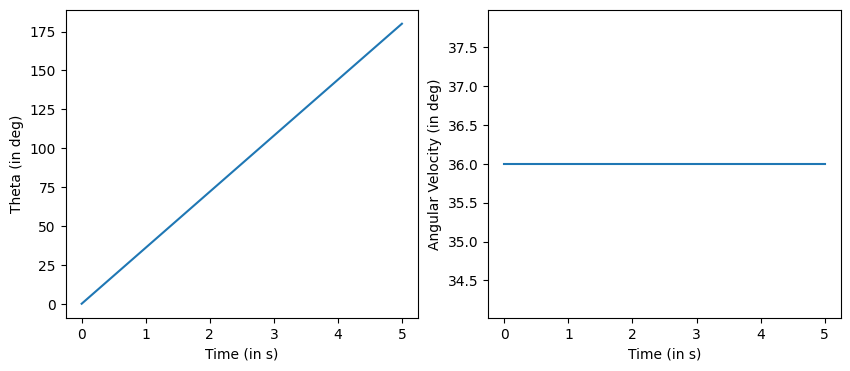

In [48]:
fig2,ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(t,ref_thetas)
ax[0].set_xlabel("Time (in s)")
ax[0].set_ylabel("Theta (in deg)")

ax[1].plot(t,ref_w)
ax[1].set_xlabel("Time (in s)")
ax[1].set_ylabel("Angular Velocity (in deg)")

(-1.1, 1.1)

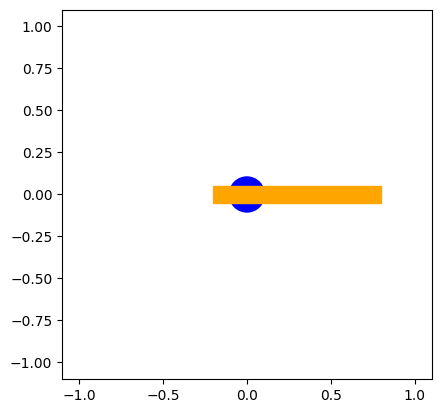

In [51]:
def control_update_func(i,kind):
    if kind==Variations.CONSTANT:
        torque = 1
    elif kind==Variations.LINEAR:
        torque = 0.1*i + 1
    elif kind==Variations.QUADRATIC:
        torque = 0.1*i**2 + 1
    elif kind==Variations.QUADRATIC:
        torque = 0.1*i**3 + 1
    joint.set_torque(torque)

In [52]:
def simulate(thetas,variation):
    start_time = time.time()  # Record the reference start time
    # time.sleep(del_t)
    print("Simulating...")
    for i in range(n):
        current_time = time.time() - start_time  # Elapsed time
        wait_time = max(0, t[i] - current_time)  # Compute time to wait before executing action
        #time.sleep(wait_time)  # Wait until the scheduled time
        plt.pause(wait_time)
        
        # Perform Action 
        joint.update_state()
        thetas[:,[i]] = joint.get_state()
        #print(f"Joint state @{time.time() - start_time:.2f}s : {joint.get_state()}")
        # joint.plot()
        # arm.plot()
        # plt.draw()  # Force update
        # plt.pause(0.01)  # Short pause to refresh plot
        control_update_func(i,variation)
    print("Done.")

In [53]:
joint.reset_state()
thetas_c = np.zeros((2,n))
simulate(thetas_c,Variations.CONSTANT)

joint.reset_state()
thetas_l = np.zeros((2,n))
simulate(thetas_l,Variations.LINEAR)

joint.reset_state()
thetas_q = np.zeros((2,n))
simulate(thetas_q,Variations.QUADRATIC)

Simulating...
Done.
Simulating...
Done.
Simulating...
Done.


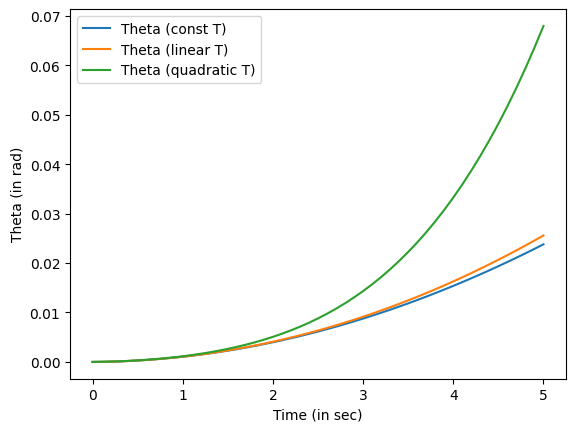

In [54]:
plt.plot(t,thetas_c[0,:]*np.pi/180,label="Theta (const T)")
plt.plot(t,thetas_l[0,:]*np.pi/180,label="Theta (linear T)")
plt.plot(t,thetas_q[0,:]*np.pi/180,label="Theta (quadratic T)")
plt.xlabel("Time (in sec)")
plt.ylabel("Theta (in rad)")
plt.legend()
plt.show()

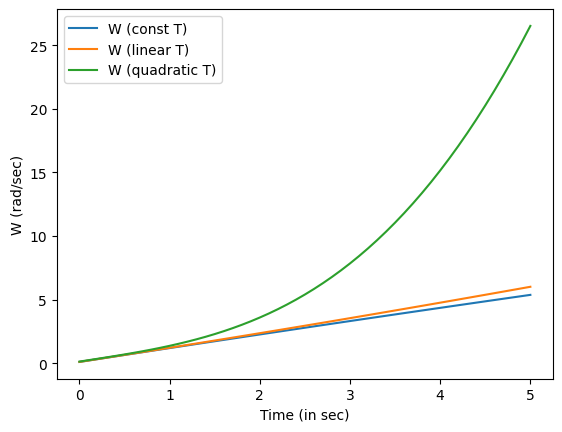

In [55]:
plt.plot(t,thetas_c[1,:],label="W (const T)")
plt.plot(t,thetas_l[1,:],label="W (linear T)")
plt.plot(t,thetas_q[1,:],label="W (quadratic T)")
plt.xlabel("Time (in sec)")
plt.ylabel("W (rad/sec)")
plt.legend()
plt.show()

In [242]:

# Plot results
plt.figure(figsize=(10, 7))

# Plot theta vs time
plt.subplot(3, 1, 1)
plt.plot(t, theta_r, label="Reference Theta", linestyle="dashed")
plt.plot(t, theta_actual, label="Actual Theta", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Theta (rad)")
plt.legend()
plt.title("Joint Position Tracking")

# Plot theta_d vs time
plt.subplot(3, 1, 2)
plt.plot(t, theta_d_r, label="Reference Theta_d", linestyle="dashed")
plt.plot(t, theta_d_actual, label="Actual Theta_d", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Theta_d (rad/s)")
plt.legend()
plt.title("Rotation Rate Tracking")

# Plot control input vs time
plt.subplot(3, 1, 3)
plt.plot(t, control_inputs, label="Control Input (Torque)")
plt.xlabel("Time (s)")
plt.ylabel("Torque (Nm)")
plt.legend()
plt.title("Control Input Over Time")

plt.tight_layout()
plt.show()


(array([[8],
        [7]]),
 array([[10, 12, 14, 16, 17],
        [10, 13, 14, 15, 16]]))

In [243]:
mpc.get_control_input(X0,Xr)

array([2.39821497e-06])

In [244]:
start_time = time.time()  # Record the reference start time
# time.sleep(del_t)
for i in range(n):
    current_time = time.time() - start_time  # Elapsed time
    wait_time = max(0, t[i] - current_time)  # Compute time to wait before executing action
    time.sleep(wait_time)  # Wait until the scheduled time

    # Perform Action 
    [[cur_theta],[cur_theta_d]] = joint.get_state()
    ref_theta,ref_theta_d = ref_thetas[i],ref_theta_ds[i]
    print(f" Current Time: {time.time() - start_time:.2f}s Current angle: {cur_theta}deg. Current rotation rate: {cur_theta_d}deg./s")
    print(f" Ref Time: {t[i]:.2f}s Ref angle: {ref_theta:.2f}deg. Ref rotation rate: {ref_theta_d}deg./s\n")

    theta = ref_theta-cur_theta
    
    # joint.rotate_by(theta)
    print("Before state :",joint.get_state())
    joint.set_torque(1)
    print(joint.get_state_space())
    print("After state :",joint.get_state())
    arm.plot()
    plt.pause(0.1)
    plt.draw()
    plt.show()

# theta_dd,theta_d = joint.get_state_space()
# toc = time.time_ns()
# del_t = round((toc-tic)/1e9,3)
# theta_d_c = np.round(theta/del_t,3)
# theta_d_a = np.round(theta/0.1,3)
# print(f"del_t = {del_t} theta_d_c = {theta_d_c} theta_d_a = {theta_d_a}")

plt.show()

NameError: name 'ref_theta_ds' is not defined

In [393]:
import numpy as np
import scipy.linalg

# System Parameters
J = 1.0   # Moment of inertia
b = 0.1   # Damping coefficient
K = 1.0   # Stiffness

# MPC Parameters
dt = 0.01  # Time step
N = 20     # Prediction horizon
Q = np.diag([10, 1])  # State cost (higher weight on theta)
R = np.array([[0.1]])  # Control cost

# State-Space Matrices (Discretized)
A = np.array([[1, dt], [-K * dt / J, 1 - (b * dt / J)]])
B = np.array([[0], [dt / J]])

# Initial & Reference State
X = np.array([[np.pi / 4], [0]])  # Initial state (theta = 45 deg, theta_d = 0)
X_ref = np.array([[0], [0]])  # Desired (zero position & velocity)
X,X_ref

(array([[0.7854],
        [0.    ]]),
 array([[0],
        [0]]))

In [396]:
# Control Input Initialization
U = np.zeros((1, N))  # Control input for horizon

In [397]:

# Solve for Optimal Control Using LQR Approximation
P = scipy.linalg.solve_discrete_are(A, B, Q, R)
K_mpc = np.linalg.inv(R + B.T @ P @ B) @ (B.T @ P @ A)

In [334]:
mpc = MPC(joint, N=10)

# Time settings
T = 5
del_t = 0.1
t = np.arange(0, T + del_t, del_t)

# Reference trajectory (Sinusoidal)
theta_r = np.sin(0.5 * t)  # Position reference
theta_d_r = 0.5 * np.cos(0.5 * t)  # Velocity reference

# Data storage
theta_actual = []
theta_d_actual = []
control_inputs = []

joint.reset_state()  # Reset initial state
X0 = joint.get_state()  # Get initial state

In [335]:
# MPC Execution Loop
for i in range(len(t)):
    Xr = np.array([[theta_r[i]], [theta_d_r[i]]])  # Reference state
    
    u_opt = mpc.get_control_input(X0, Xr)  # Get optimal control input
    joint.update_state(u_opt.item())  # Apply torque

    X0 = joint.get_state()  # Update state

    # Store results
    theta_actual.append(X0[0, 0])
    theta_d_actual.append(X0[1, 0])
    control_inputs.append(u_opt[0])

TypeError: float() argument must be a string or a real number, not 'Vector'

In [325]:




# Plot results
plt.figure(figsize=(10, 7))

plt.subplot(3, 1, 1)
plt.plot(t, theta_r, label="Reference Theta", linestyle="dashed")
plt.plot(t, theta_actual, label="Actual Theta", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Theta (rad)")
plt.legend()
plt.title("Joint Position Tracking")

plt.subplot(3, 1, 2)
plt.plot(t, theta_d_r, label="Reference Theta_d", linestyle="dashed")
plt.plot(t, theta_d_actual, label="Actual Theta_d", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Theta_d (rad/s)")
plt.legend()
plt.title("Rotation Rate Tracking")

plt.subplot(3, 1, 3)
plt.plot(t, control_inputs, label="Control Input (Torque)")
plt.xlabel("Time (s)")
plt.ylabel("Torque (Nm)")
plt.legend()
plt.title("Control Input Over Time")

plt.tight_layout()
plt.show()


AttributeError: 'int' object has no attribute 'z'